In [1]:
import os
import time
import requests
import pandas as pd
from zipfile import ZipFile
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
combined_consolidated_df = pd.read_csv("df_final.csv")

In [4]:
# Detailed column stats sorted by non-null count (descending)
col_stats = pd.DataFrame({
    'non_null_count': combined_consolidated_df.notna().sum(),
    'null_count': combined_consolidated_df.isna().sum(),
    'unique_count': combined_consolidated_df.nunique(dropna=True)
}).sort_values('non_null_count', ascending=False)



In [5]:
combined_consolidated_df['surveyyear'].value_counts()

,count
surveyyear,
2018,98855
2016,56030
2017,51392
2015,26086
2013,9742
2019,9286
2014,7643
2012,6243
2011,2813


In [6]:
# Add percent of total rows for nulls (rounded to 2 decimals)
total_rows = combined_consolidated_df.shape[0]
col_stats['null_pct'] = (col_stats['null_count'] / total_rows * 100).round(2)

In [7]:
col_stats.head(50)

,non_null_count,null_count,unique_count,null_pct
Unnamed: 0,268090,0,268090,0.00
surveyyear,268090,0,9,0.00
gender,268089,1,7,0.00
country,241088,27002,253,10.07
employment,205400,62690,13,23.38
education,200072,68018,12,25.37
company_size,174509,93581,35,34.91
dev_environment,166082,102008,16685,38.05
respondent,159532,108558,100265,40.49
years_coding,157152,110938,50,41.38


In [8]:
print(sorted(combined_consolidated_df['surveyyear'].dropna().unique()))

[np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]


### Analyze by Country

#### Trend over time

In [9]:
# extract surveyyear and country and make a counts matrix
cols = ['surveyyear', 'country']
df_sub = combined_consolidated_df[cols].copy()

# drop rows missing either value
#df_sub = df_sub.dropna(subset=['surveyyear', 'country'])

# ensure surveyyear is treated consistently (optional)
# df_sub['surveyyear'] = df_sub['surveyyear'].astype(str)

# Create matrix: rows = surveyyear, cols = country, values = counts
matrix_df = pd.crosstab(df_sub['surveyyear'], df_sub['country']).sort_index()

# display and optionally save
display(matrix_df)


country,Afghanistan,Africa,Aland Islands,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antarctica,Antigua & Deps,Antigua and Barbuda,Argentina,Armenia,Aruba,Australasia,Australia,Austria,Azerbaidjan,Azerbaijan,Bahamas,Bahrain,Bangladesh,Barbados,Belarus,Belgium,Belize,Benin,Bermuda,Bhutan,Bolivia,Bosnia and Herzegovina,Botswana,Bouvet Island,Brazil,British Indian Ocean Territory,Brunei Darussalam,Bulgaria,Burkina,Burkina Faso,Burundi,Cambodia,Cameroon,Canada,Cape Verde,Cayman Islands,Central African Rep,Central African Republic,Central America,Chad,Chile,China,Christmas Island,Colombia,Comoros,"Congo, Republic of the...",Cook Islands,Costa Rica,Croatia,Cuba,Cyprus,Czech Republic,Côte d'Ivoire,Democratic People's Republic of Korea,Democratic Republic of the Congo,Denmark,Djibouti,Dominica,Dominican Republic,East Timor,Ecuador,Egypt,El Salvador,Eritrea,Estonia,Ethiopia,Falkland Islands,Fiji,Finland,France,French Guyana,Gabon,Gambia,Georgia,Germany,Ghana,Gibraltar,Greece,Grenada,Guam,Guatemala,Guinea,Guyana,Haiti,Heard and McDonald Islands,Honduras,Hong Kong,Hungary,I prefer not to say,Iceland,India,Indonesia,Iran,"Iran, Islamic Republic of...",Iraq,Ireland,Israel,Italy,Ivory Coast,Ivory Coast (Cote D'Ivoire),Jamaica,Japan,Jordan,Kazakhstan,Kenya,Kosovo,Kuwait,Kyrgyzstan,Laos,Latvia,Lebanon,Lesotho,Liberia,Libya,Liechtenstein,Lithuania,Luxembourg,Macau,Macedonia,Macedonia [FYROM],Madagascar,Malawi,Malaysia,Maldives,Mali,Malta,Marshall Islands,Martinique (French),Mauritania,Mauritius,Mexico,Micronesia,"Micronesia, Federated States of...",Middle East,Moldavia,Moldova,Monaco,Mongolia,Montenegro,Montserrat,Morocco,Mozambique,Myanmar,Myanmar [Burma],Namibia,Nauru,Nepal,Netherlands,Netherlands Antilles,New Caledonia (French),New Zealand,Nicaragua,Niger,Nigeria,North America (Other),North Korea,Northern Mariana Islands,Norway,Oman,Other,Other Asia,Other Europe,Pakistan,Palau,Palestine,Panama,Paraguay,Peru,Philippines,Pitcairn Island,Poland,Polynesia (French),Portugal,Puerto Rico,Qatar,Republic of Moldova,Reunion (French),Romania,Russia,Russian Federation,Rwanda,S. Georgia & S. Sandwich Isls.,Saint Helena,Saint Lucia,Saint Vincent & Grenadines,San Marino,Sao Tome & Principe,Saudi Arabia,Senegal,Serbia,Seychelles,Sierra Leone,Singapore,Slovak Republic,Slovakia,Slovenia,Solomon Islands,Somalia,South Africa,South America,South Korea,Spain,Sri Lanka,St Kitts & Nevis,Sudan,Suriname,Swaziland,Sweden,Switzerland,Syria,Tadjikistan,Taiwan,Tajikistan,Tanzania,Thailand,The former Yugoslav Republic of Macedonia,Timor-Leste,Togo,Trinidad and Tobago,Tunisia,Turkey,Turkmenistan,U.S. Minor Outlying Islands,Uganda,Ukraine,United Arab Emirates,United Kingdom,United Republic of Tanzania,United States,Uruguay,Uzbekistan,Vanuatu,Vatican,Vatican City,Venezuela,"Venezuela, Bolivarian Republic of...",Vietnam,Virgin Islands (British),Virgin Islands (USA),Yemen,Zaire,Zambia,Zimbabwe
surveyyear,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2011,0,43,0,0,0,0,0,0,0,0,0,0,0,0,0,29,112,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,156,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,60,0,0,0,0,106,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,95,0,0,0,0,0,0,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,20,0,0,73,0,0,0,0,0,0,0,0,0,0,0,0,0,55,0,0,0,0,0,0,8,0,0,0,0,0,81,451,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,91,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,314,0,1037,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2012,0,92,0,0,0,0,0,0,0,0,0,0,0,0,0,105,185,0,0,0,0,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,348,0,0,0,0,21,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,135,0,0,0,0,273,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,537,0,0,0,0,0,0,110,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

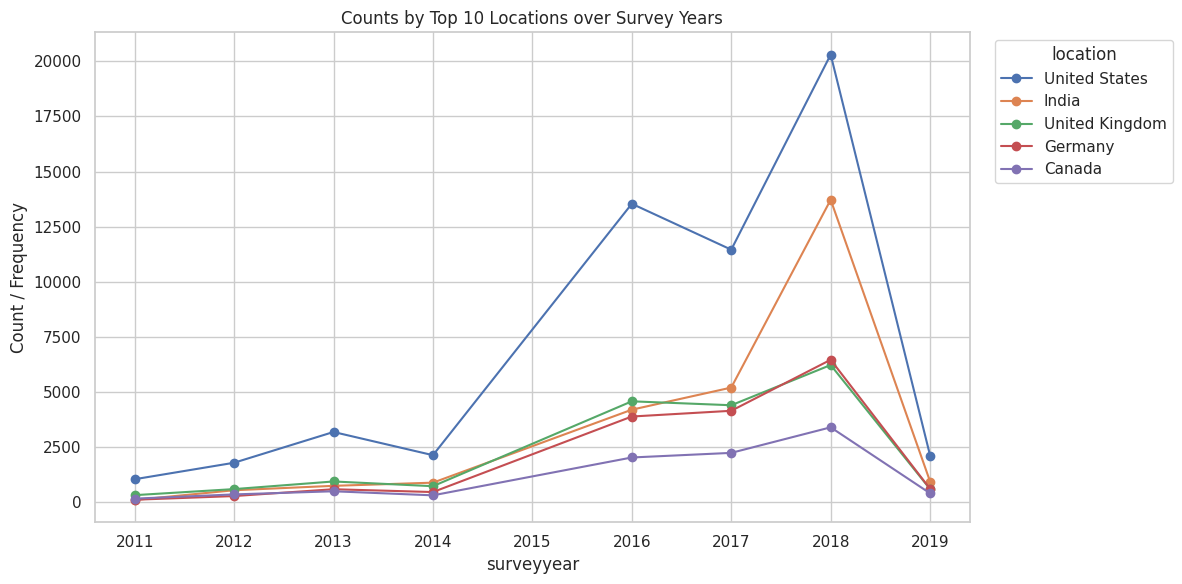

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# prepare a plotting-friendly copy (try numeric years first, otherwise keep strings)
matrix_plot = matrix_df.copy()
years_numeric = pd.to_numeric(matrix_plot.index, errors='coerce')
if years_numeric.notna().all():
    matrix_plot.index = years_numeric
matrix_plot = matrix_plot.sort_index()

# Select top 10 countries by total count
top_countries = matrix_plot.sum(axis=0).sort_values(ascending=False).head(5).index
matrix_plot_top = matrix_plot[top_countries]

sns.set(style='whitegrid')
ax = matrix_plot_top.plot(kind='line', figsize=(12,6), marker='o', linewidth=1.5)
ax.set_xlabel('surveyyear')
ax.set_ylabel('Count / Frequency')
ax.set_title('Counts by Top 10 Locations over Survey Years')
ax.legend(title='location', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

# Save and show
plt.show()


#### Overall by country

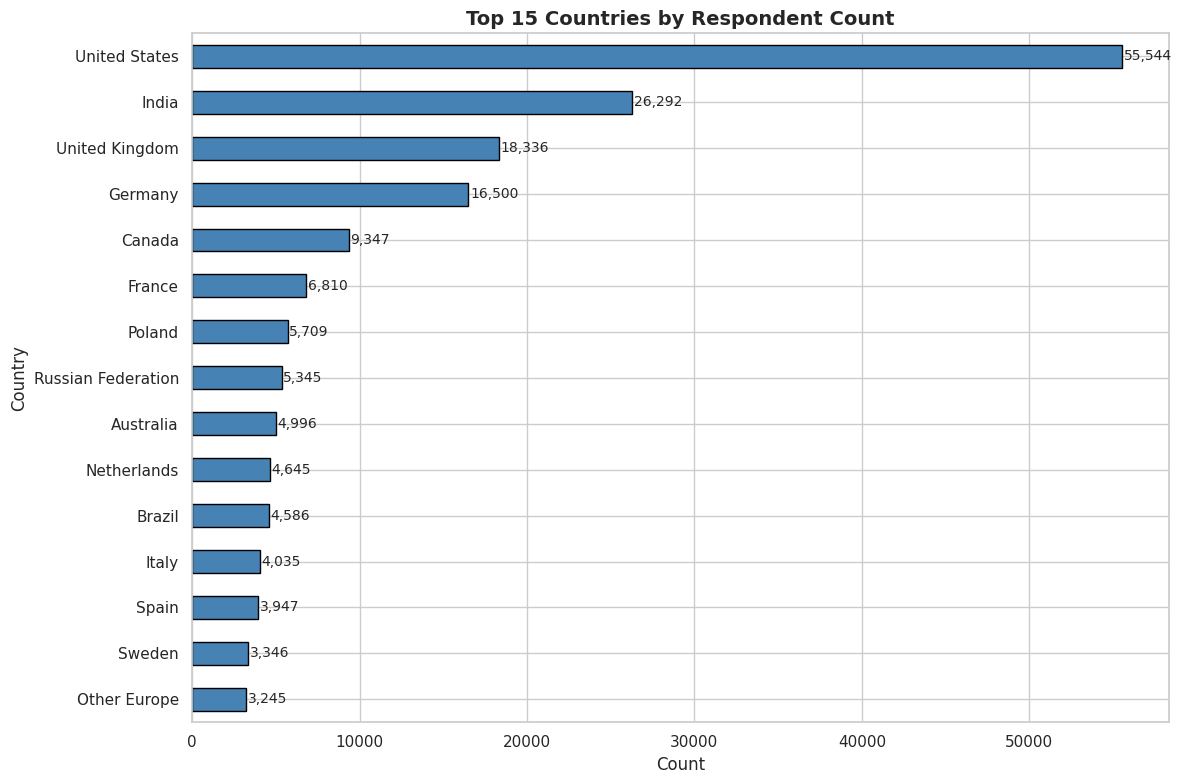

In [11]:
# Get country counts and select top 15
country_counts = combined_consolidated_df['country'].value_counts().head(15)

# Create bar chart
plt.figure(figsize=(12, 8))
sns.set(style='whitegrid')

ax = country_counts.plot(kind='barh', color='steelblue', edgecolor='black')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('Top 15 Countries by Respondent Count', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Highest count at the top

# Add value labels on bars
for i, v in enumerate(country_counts.values):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Education Analysis

#### Trend for Education

In [12]:
# Create education by survey year matrix
cols = ['surveyyear', 'education']
df_edu = combined_consolidated_df[cols].copy()

# Create matrix: rows = surveyyear, cols = education, values = counts
education_matrix = pd.crosstab(df_edu['surveyyear'], df_edu['education']).sort_index()

display(education_matrix)

education,Professional degree,associate degree,bachelors,doctoral degree,i prefer not to say,less than college,masters,none,on the job training,other program,self-taught,some college
surveyyear,,,,,,,,,,,,
2016,0,0,18758,223,0,0,5370,0,932,408,18490,774
2017,715,0,29738,1308,1109,6955,11141,426,0,0,0,0
2018,0,2970,43659,3661,0,10607,21396,700,0,0,0,11710
2019,0,275,4108,338,0,1077,2082,56,0,0,0,1086


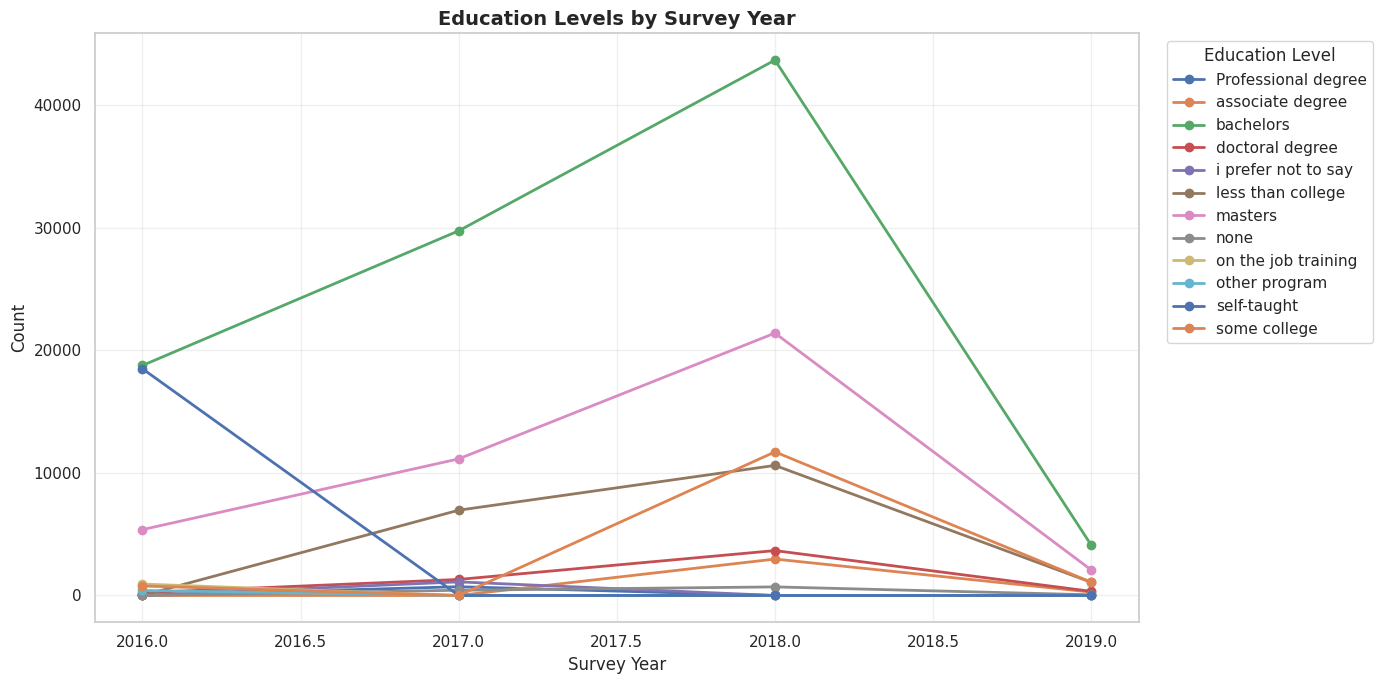

In [13]:
# Create line chart for education levels over time
education_plot = education_matrix.copy()

# Convert years to numeric if possible
years_numeric = pd.to_numeric(education_plot.index, errors='coerce')
#if years_numeric.notna().all():
#    education_plot.index = years_numeric
education_plot = education_plot.sort_index()

# Create the line chart
sns.set(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each education level
for col in education_plot.columns:
    ax.plot(education_plot.index, education_plot[col], marker='o', linewidth=2, label=col)

ax.set_xlabel('Survey Year', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Education Levels by Survey Year', fontsize=14, fontweight='bold')
ax.legend(title='Education Level', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Overall education

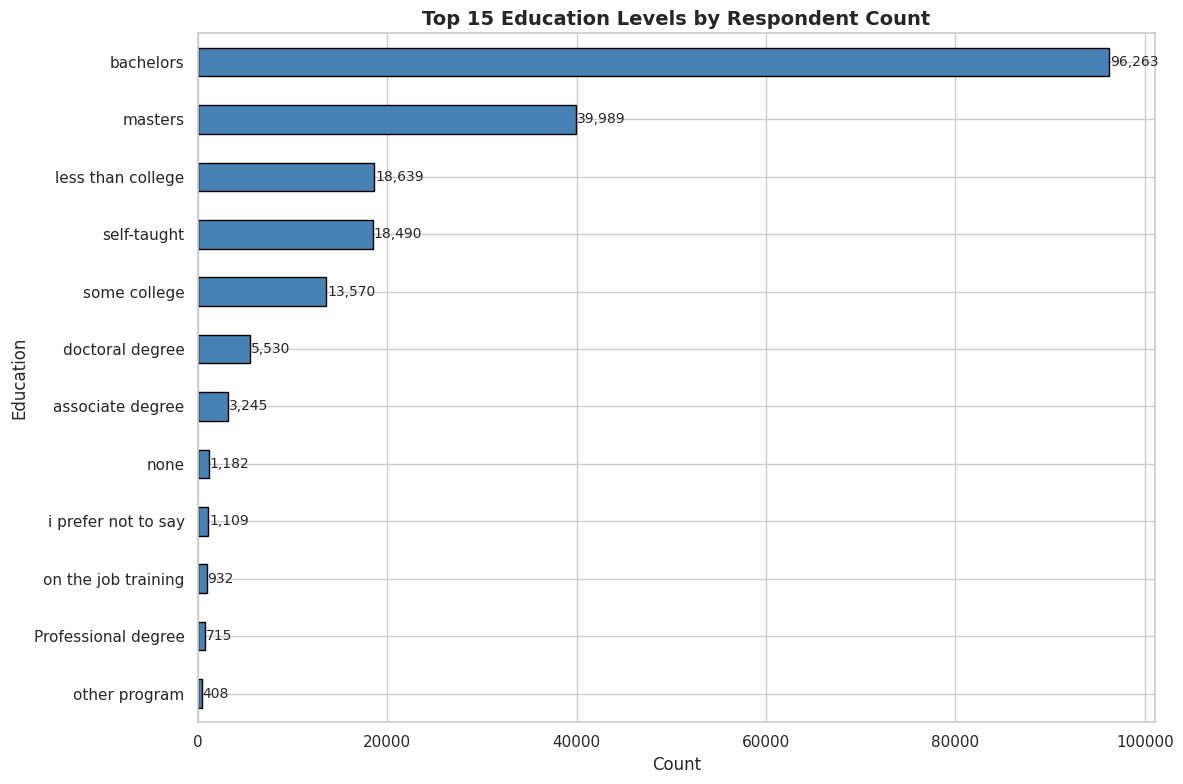

In [14]:
# Get country counts and select top 15
education_counts = combined_consolidated_df['education'].value_counts().head(15)

# Create bar chart
plt.figure(figsize=(12, 8))
sns.set(style='whitegrid')

ax = education_counts.plot(kind='barh', color='steelblue', edgecolor='black')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Education', fontsize=12)
ax.set_title('Top 15 Education Levels by Respondent Count', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Highest count at the top

# Add value labels on bars
for i, v in enumerate(education_counts.values):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Developer Type Analysis

#### Trend Analysis

In [15]:
# extract surveyyear and country and make a counts matrix
cols = ['surveyyear', 'developer_type_clean']
df_dev = combined_consolidated_df[cols].copy()

# Create matrix: rows = surveyyear, cols = country, values = counts
matrix_df_dev = pd.crosstab(df_dev['surveyyear'], df_dev['developer_type_clean']).sort_index()
# display and optionally save
display(matrix_df_dev)

developer_type_clean,back-end developer,data role,data scientist,design,educator,engineering role,executive,front-end developer,full-stack developer,marketing or sales professional,other developer,other role,product/project manager,research role,student,systems administrator
surveyyear,,,,,,,,,,,,,,,,
2017,0,140,846,13,0,109,0,0,0,0,33730,1174,0,0,0,113
2018,53300,3794,2211,2691,0,912,1195,5432,7384,91,10505,0,186,792,3300,305
2019,2731,1248,328,564,18,64,41,514,1260,7,916,0,12,638,153,28


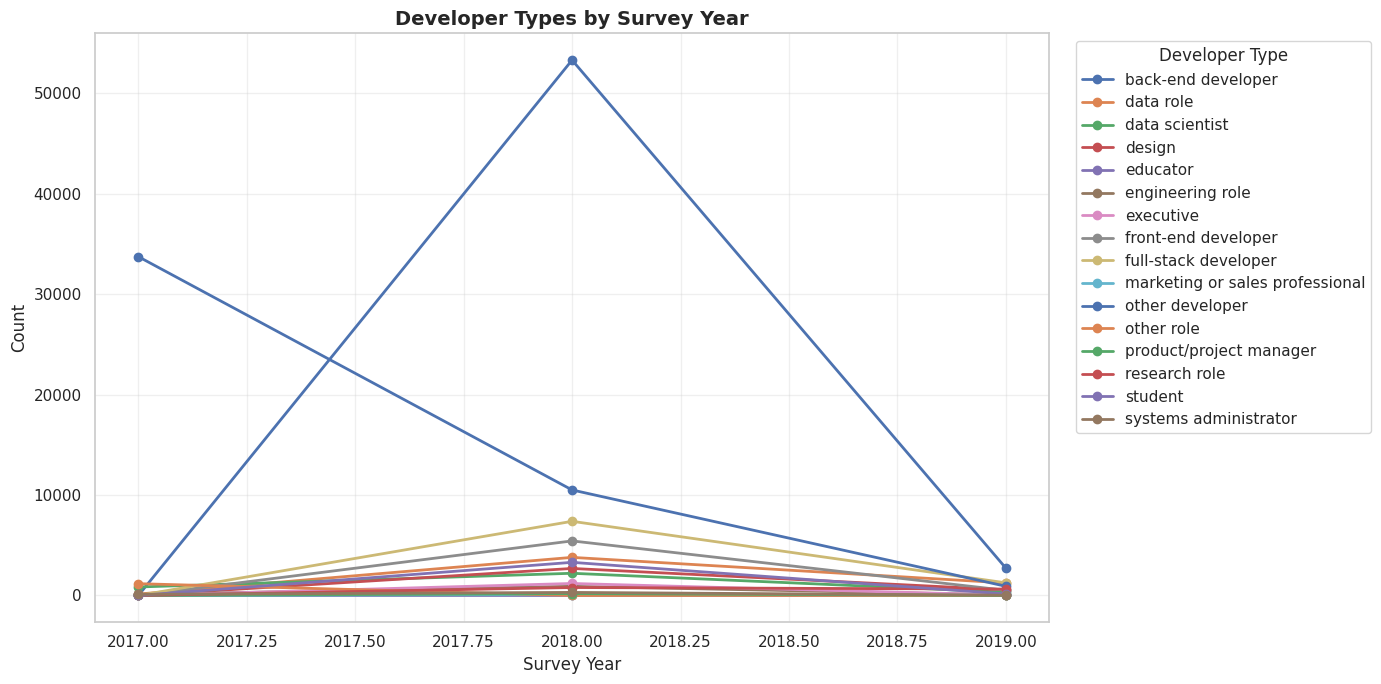

In [16]:
# Create line chart for education levels over time
dev_plot = matrix_df_dev.copy()

# Convert years to numeric if possible
years_numeric = pd.to_numeric(dev_plot.index, errors='coerce')
if years_numeric.notna().all():
    dev_plot.index = years_numeric
dev_plot = dev_plot.sort_index()

# Create the line chart
sns.set(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each education level
for col in dev_plot.columns:
    ax.plot(dev_plot.index, dev_plot[col], marker='o', linewidth=2, label=col)

ax.set_xlabel('Survey Year', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Developer Types by Survey Year', fontsize=14, fontweight='bold')
ax.legend(title='Developer Type', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Overall Analysis

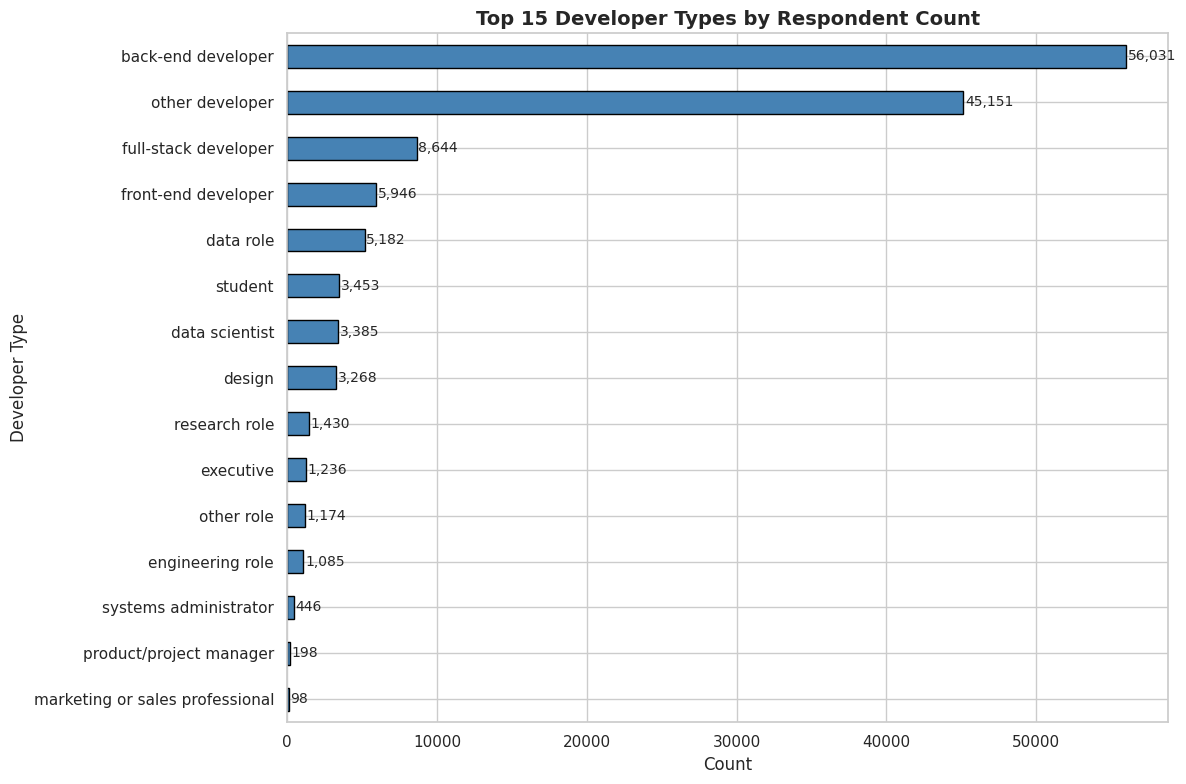

In [17]:
# Get country counts and select top 15
developer_counts = combined_consolidated_df['developer_type_clean'].value_counts().head(15)

# Create bar chart
plt.figure(figsize=(12, 8))
sns.set(style='whitegrid')

ax = developer_counts.plot(kind='barh', color='steelblue', edgecolor='black')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Developer Type', fontsize=12)
ax.set_title('Top 15 Developer Types by Respondent Count', fontsize=14, fontweight='bold')
ax.invert_yaxis()  # Highest count at the top

# Add value labels on bars
for i, v in enumerate(developer_counts.values):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Regional Differences

#### Developer Type by Country

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Create developer type by country matrix for top countries
cols = ['country', 'developer_type_clean']
df_country_dev = combined_consolidated_df[cols].dropna()

top_countries = df_country_dev['country'].value_counts().head(15).index

# Use same top 10 countries for consistency
df_country_dev_top = df_country_dev[df_country_dev['country'].isin(top_countries)]

# Create crosstab
country_dev_matrix = pd.crosstab(df_country_dev_top['country'], df_country_dev_top['developer_type_clean'])

# Sort by total count (descending)
country_dev_matrix = country_dev_matrix.loc[country_dev_matrix.sum(axis=1).sort_values(ascending=False).index]

display(country_dev_matrix)

developer_type_clean,back-end developer,data role,data scientist,design,educator,engineering role,executive,front-end developer,full-stack developer,marketing or sales professional,other developer,other role,product/project manager,research role,student,systems administrator
country,,,,,,,,,,,,,,,,
United States,11226,1299,908,714,6,389,249,1348,2258,25,9779,377,51,279,629,118
India,7017,461,332,493,0,114,126,1052,1131,9,5279,88,17,105,550,33
United Kingdom,3599,358,240,167,2,70,82,387,705,8,3692,142,9,70,183,39
Germany,3734,352,297,184,1,45,75,324,427,4,3416,90,21,146,253,28
Canada,1923,181,114,125,1,41,47,190,370,4,1933,57,9,35,149,16
France,1473,116,150,52,1,33,42,112,278,1,1427,33,6,38,76,15
Russian Federation,1583,129,77,52,1,29,29,161,138,3,1066,14,5,37,79,11
Brazil,1583,109,55,78,1,9,35,130,216,0,757,4,6,37,76,14
Poland,1297,77,57,67,0,14,21,124,142,1,1206,22,1,25,46,7


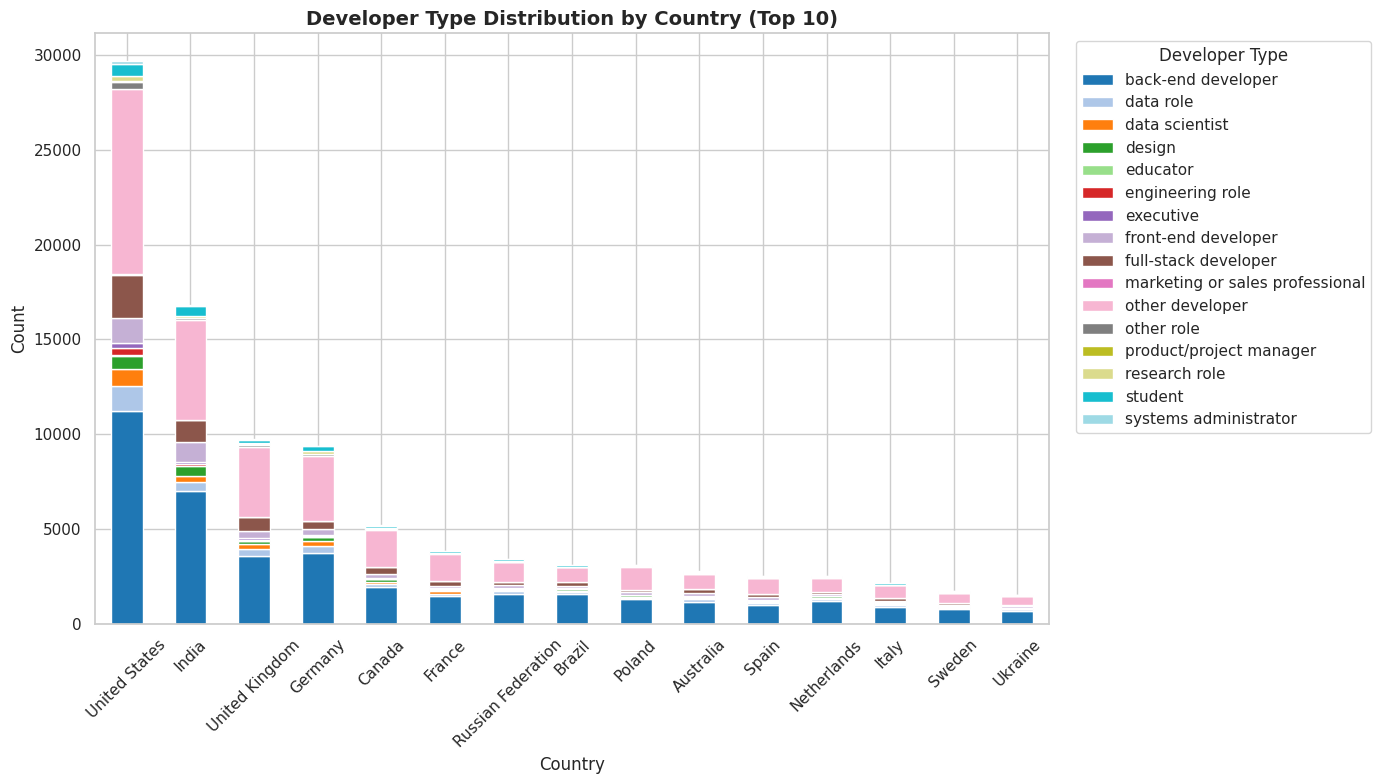

In [20]:
# Create stacked bar chart for developer type by country
fig, ax = plt.subplots(figsize=(14, 8))

country_dev_matrix.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Developer Type Distribution by Country (Top 10)', fontsize=14, fontweight='bold')
ax.legend(title='Developer Type', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

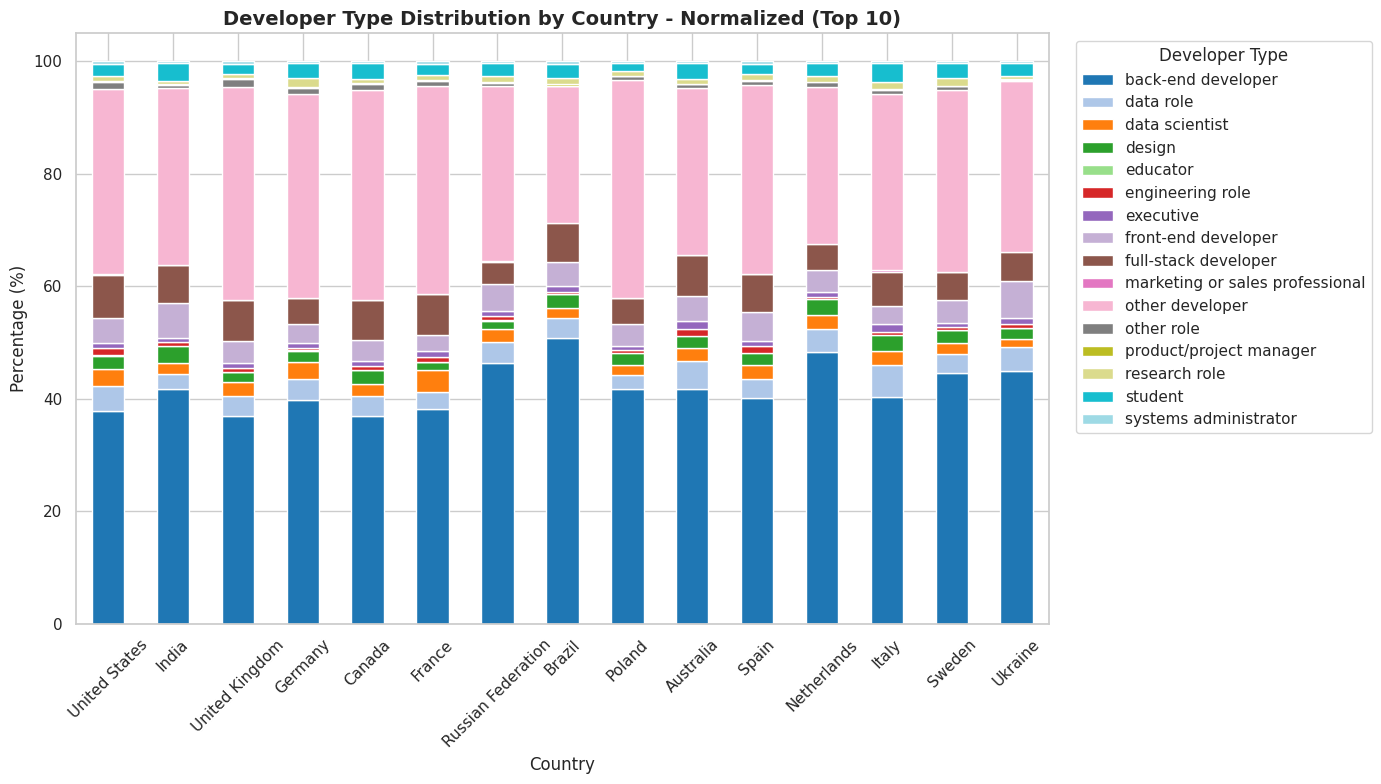

In [21]:
# Create normalized (percentage) view for developer type
country_dev_pct = country_dev_matrix.div(country_dev_matrix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))

country_dev_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Developer Type Distribution by Country - Normalized (Top 10)', fontsize=14, fontweight='bold')
ax.legend(title='Developer Type', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

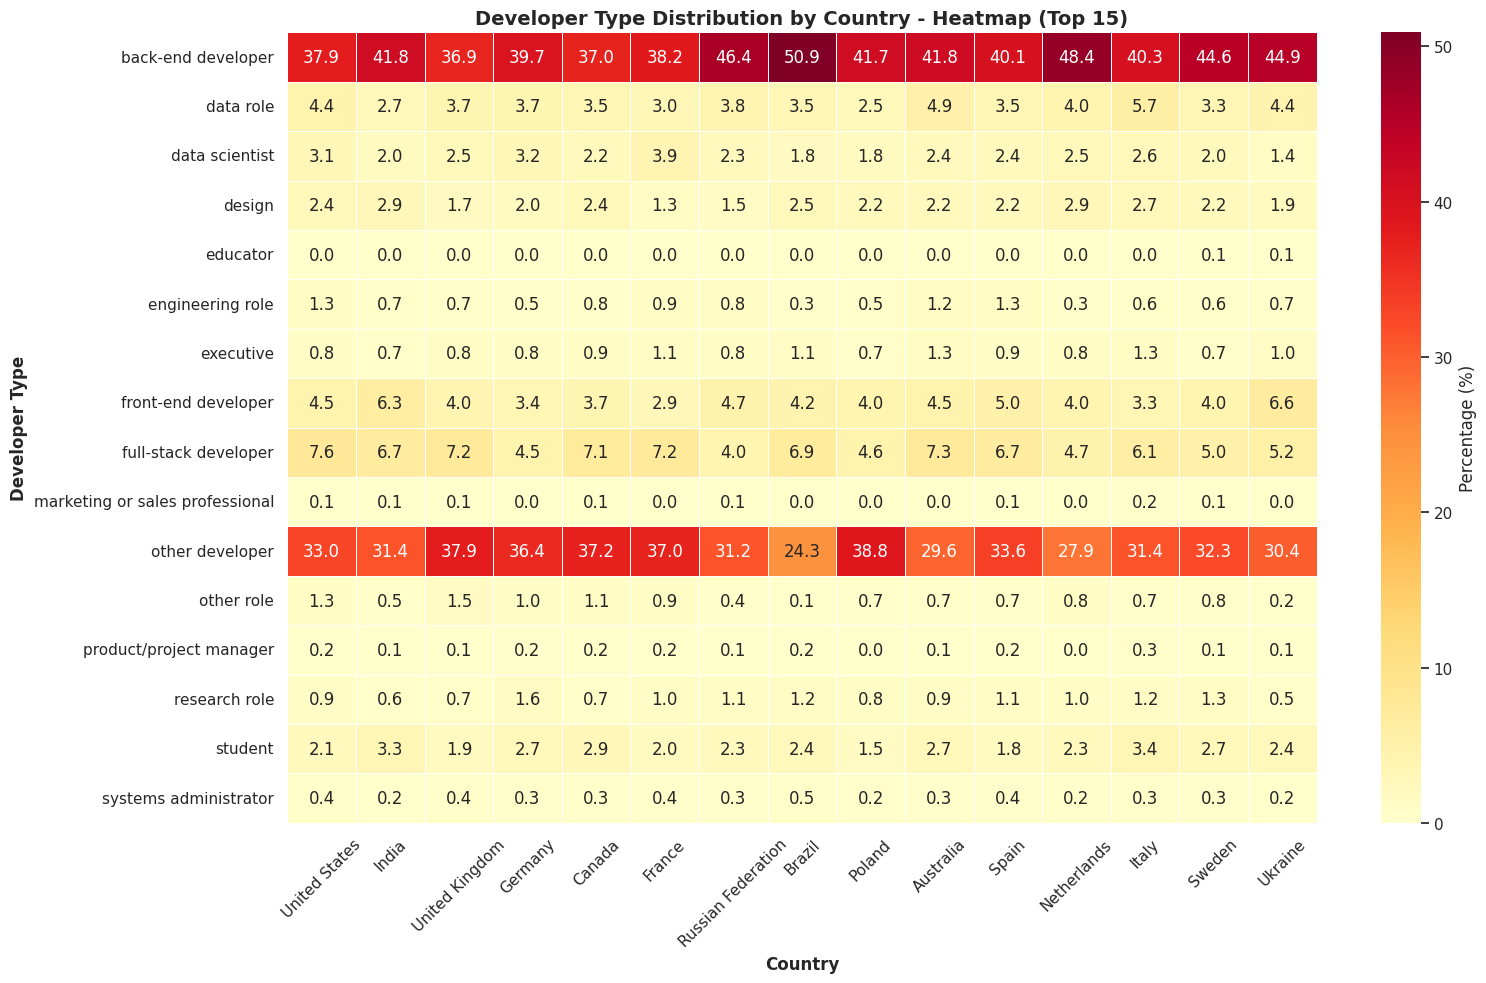

In [22]:
# Create heatmap for developer type by country
fig, ax = plt.subplots(figsize=(16, 10))

# Use normalized percentages for better comparison across countries
sns.heatmap(country_dev_pct.T, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Percentage (%)'}, ax=ax, linewidths=0.5)

ax.set_xlabel('Country', fontsize=12, fontweight='bold')
ax.set_ylabel('Developer Type', fontsize=12, fontweight='bold')
ax.set_title('Developer Type Distribution by Country - Heatmap (Top 15)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

#### Education by Country

In [23]:
# Create education by country matrix for top countries
cols = ['country', 'education']
df_country_edu = combined_consolidated_df[cols].dropna()

# Get top 15 countries by respondent count
top_countries = df_country_edu['country'].value_counts().head(15).index

# Get top 15 countries by respondent count
top_edu = df_country_edu['education'].value_counts().head(5).index

# Filter to top countries
df_country_edu_top = df_country_edu[df_country_edu['country'].isin(top_countries) & df_country_edu['education'].isin(top_edu)]

# Create crosstab
country_edu_matrix = pd.crosstab(df_country_edu_top['country'], df_country_edu_top['education'])

# Sort by total count (descending)
country_edu_matrix = country_edu_matrix.loc[country_edu_matrix.sum(axis=1).sort_values(ascending=False).index]

display(country_edu_matrix)

education,bachelors,less than college,masters,self-taught,some college
country,,,,,
United States,24961,2629,6597,4910,3297
India,13195,1358,4798,1404,441
United Kingdom,7377,1293,2662,1630,1057
Germany,4511,2563,3818,1347,797
Canada,4240,683,757,652,591
France,1186,186,3206,340,172
Poland,1695,518,1687,553,348
Russian Federation,1400,431,1410,518,498
Brazil,2141,553,410,365,486


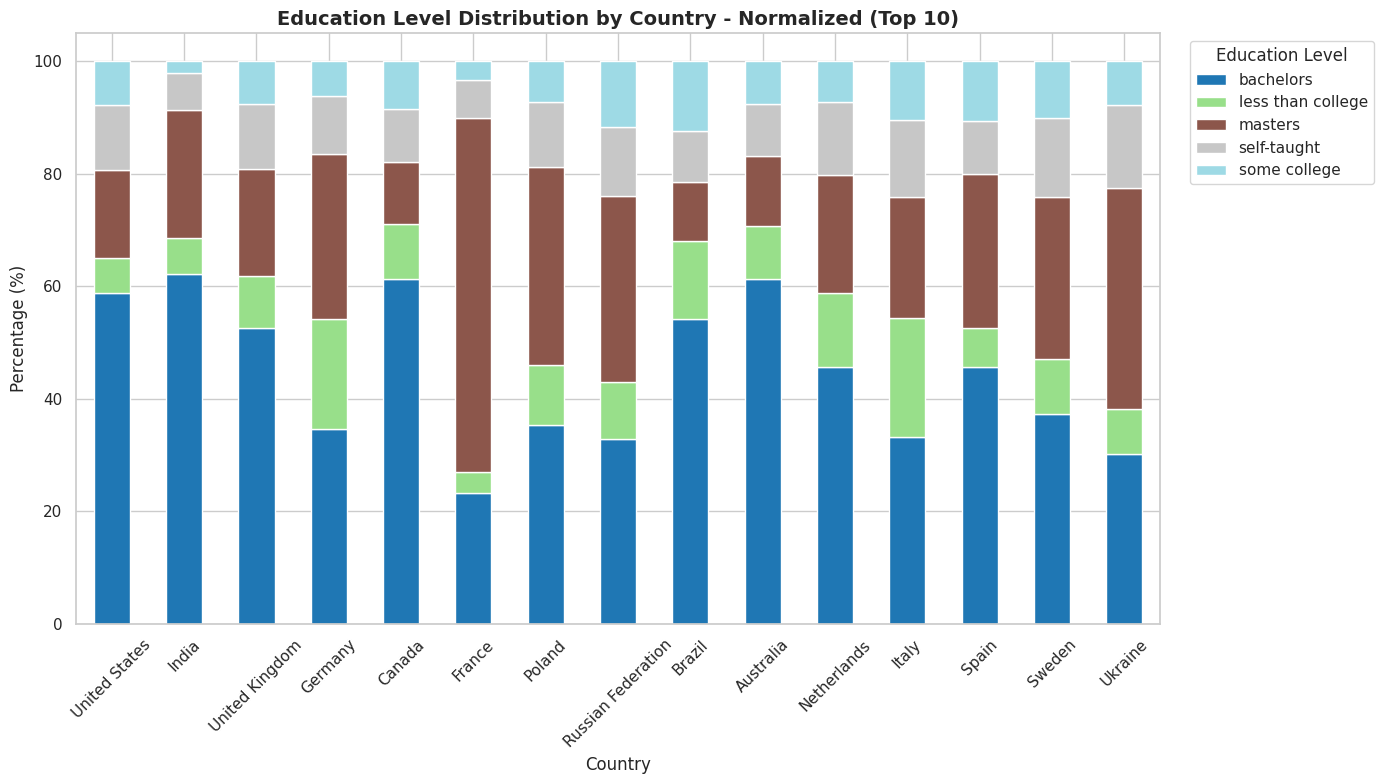

In [24]:
# Create normalized (percentage) view for better comparison
country_edu_pct = country_edu_matrix.div(country_edu_matrix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 8))

country_edu_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Education Level Distribution by Country - Normalized (Top 10)', fontsize=14, fontweight='bold')
ax.legend(title='Education Level', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

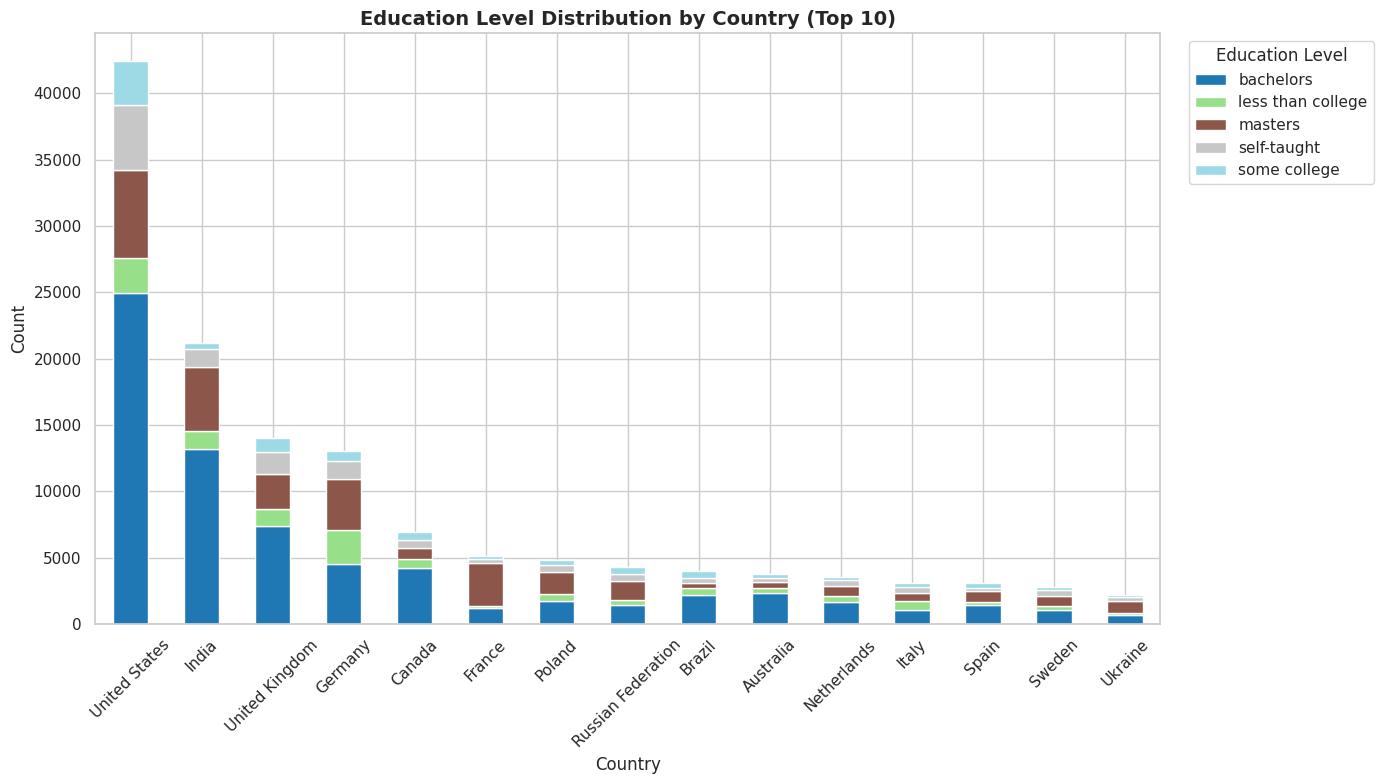

In [25]:
# Create stacked bar chart for education by country
fig, ax = plt.subplots(figsize=(14, 8))

country_edu_matrix.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Education Level Distribution by Country (Top 10)', fontsize=14, fontweight='bold')
ax.legend(title='Education Level', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

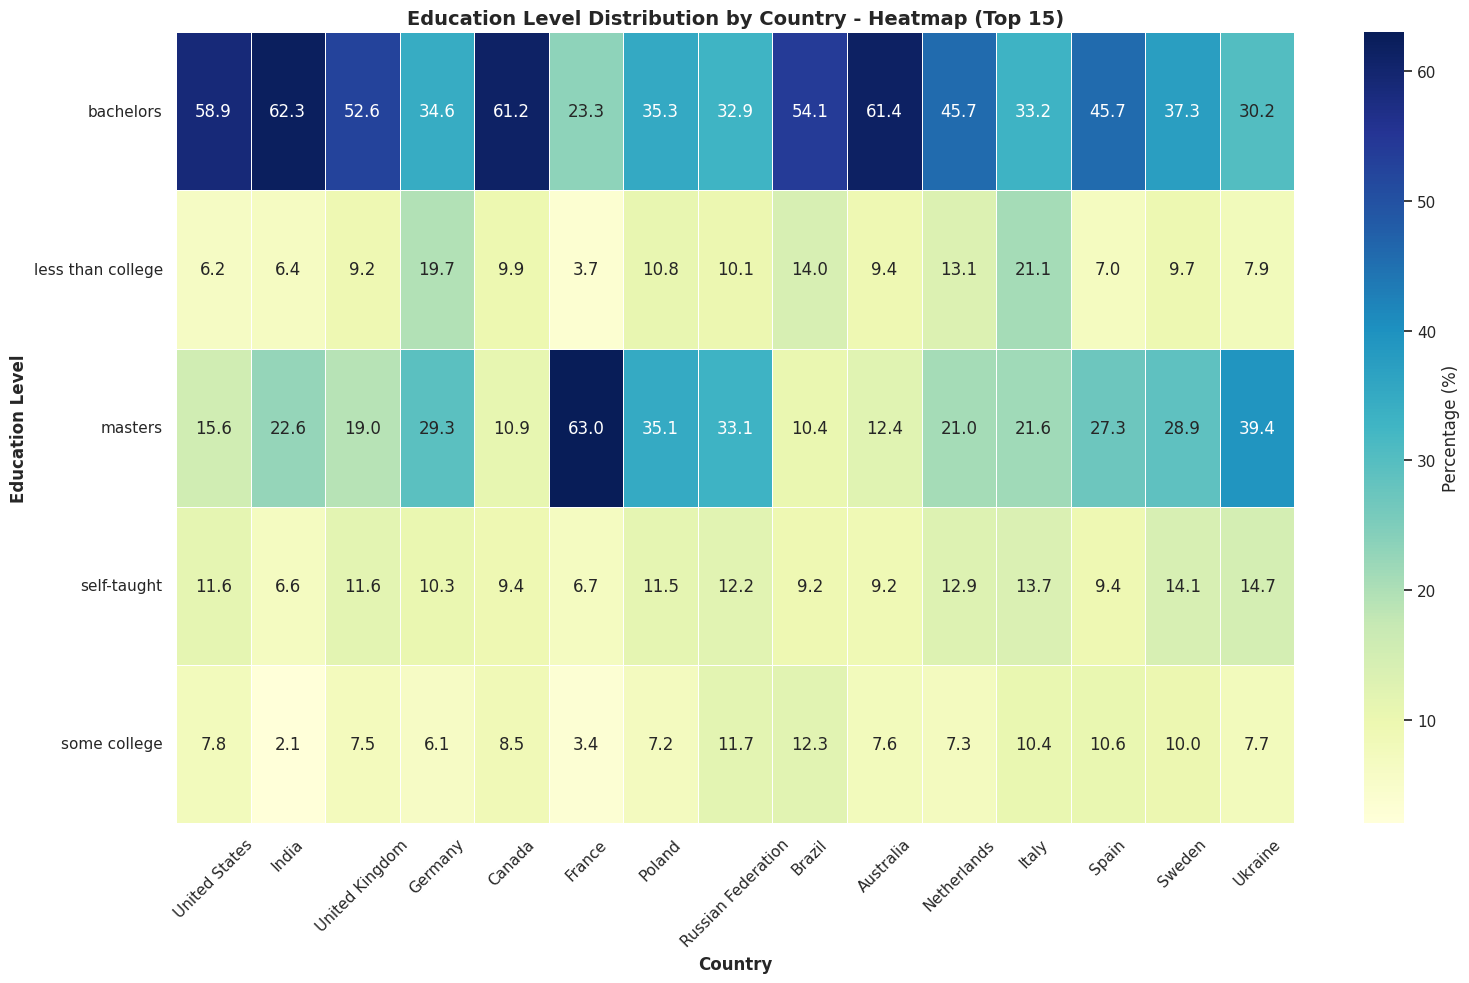

In [26]:
# Create heatmap for education by country
fig, ax = plt.subplots(figsize=(16, 10))

# Use normalized percentages for better comparison across countries
sns.heatmap(country_edu_pct.T, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': 'Percentage (%)'}, ax=ax, linewidths=0.5)

ax.set_xlabel('Country', fontsize=12, fontweight='bold')
ax.set_ylabel('Education Level', fontsize=12, fontweight='bold')
ax.set_title('Education Level Distribution by Country - Heatmap (Top 15)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [34]:
# Identify all education levels present in the matrix
all_education_levels = country_edu_pct.columns.tolist()

# Define the levels to be explicitly plotted
education_levels_explicit = ['bachelors', 'masters']

# Identify 'other' education levels
education_levels_other = [col for col in all_education_levels if col not in education_levels_explicit]

# Create a new DataFrame for plotting
country_edu_pct_with_other = pd.DataFrame()
country_edu_pct_with_other['bachelors'] = country_edu_pct['bachelors']
country_edu_pct_with_other['masters'] = country_edu_pct['masters']

# Sum the 'other' education levels into a single 'other' column
if education_levels_other:
    country_edu_pct_with_other['other'] = country_edu_pct[education_levels_other].sum(axis=1)
else:
    country_edu_pct_with_other['other'] = 0 # If no other categories, set to 0

# Ensure percentages sum to 100% for verification (optional, but good practice)
# This re-normalizes just in case there were minor floating point discrepancies
country_edu_pct_with_other = country_edu_pct_with_other.div(country_edu_pct_with_other.sum(axis=1), axis=0) * 100

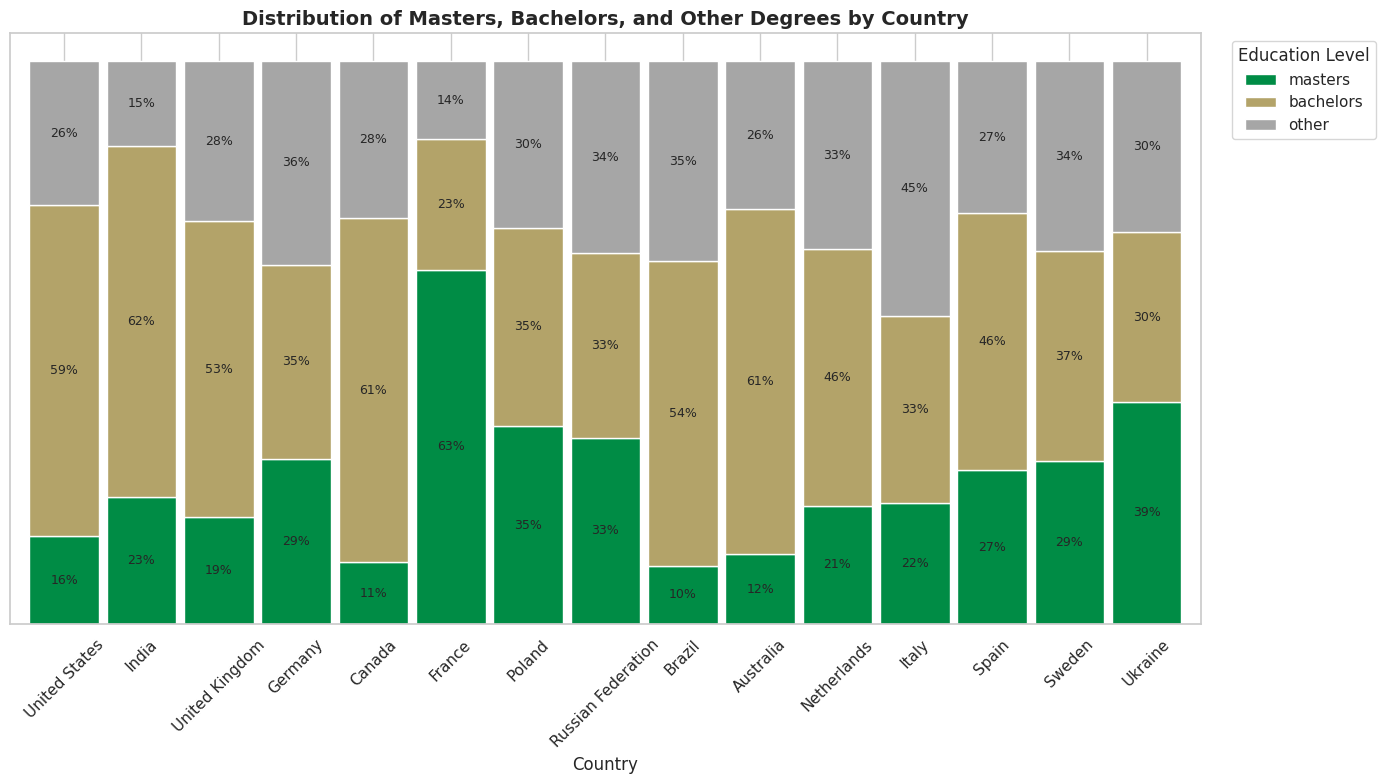

In [39]:
# Reorder columns to put 'masters' first, then 'bachelors', then 'other'
ordered_columns = ['masters', 'bachelors', 'other']
country_edu_pct_reordered = country_edu_pct_with_other[ordered_columns]

fig, ax = plt.subplots(figsize=(14, 8))

# Define custom colors for UNC Charlotte (green, gold, and a complementary color for 'other')
colors = ['#008C45', '#B3A369', '#A6A6A6'] # UNC Charlotte Green, UNC Charlotte Gold, and a grey for 'other'

country_edu_pct_reordered.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.9)

ax.set_xlabel('Country', fontsize=12)
ax.set_ylabel('') # Remove y-axis label
ax.set_title('Distribution of Masters, Bachelors, and Other Degrees by Country', fontsize=14, fontweight='bold')
ax.legend(title='Education Level', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

ax.yaxis.set_visible(False) # Remove y-axis

# Add data labels
for container in ax.containers:
    labels = [f'{w:.0f}%' if (w := v.get_height()) > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9)

plt.tight_layout()
plt.show()

### Global Map Visualization

In [27]:
# Get country counts for all countries in the dataset
country_density = combined_consolidated_df['country'].value_counts().reset_index()
country_density.columns = ['country', 'count']

display(country_density.head(20))

,country,count
0,United States,55544
1,India,26292
2,United Kingdom,18336
3,Germany,16500
4,Canada,9347
5,France,6810
6,Poland,5709
7,Russian Federation,5345
8,Australia,4996
9,Netherlands,4645


In [41]:
import plotly.express as px
import plotly.io as pio

# Set renderer for notebook
pio.renderers.default = 'notebook'

# Create choropleth map with density shading by country
fig = px.choropleth(country_density,
                    locations='country',
                    locationmode='country names',
                    color='count',
                    hover_name='country',
                    hover_data={'count': ':,', 'country': False},
                    color_continuous_scale='Plasma', # Changed color scale
                    title='Global Survey Respondent Density by Country',
                    labels={'count': 'Number of Respondents'})

fig.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='orthographic' # Changed projection type
    ),
    height=600,
    title_font_size=16,
    title_x=0.5
)

fig

In [40]:
# Alternative: Create a log-scale version for better visibility of countries with fewer respondents
import numpy as np

country_density_log = country_density.copy()
country_density_log['log_count'] = np.log10(country_density_log['count'])

fig2 = px.choropleth(country_density_log,
                     locations='country',
                     locationmode='country names',
                     color='log_count',
                     hover_name='country',
                     hover_data={'count': ':,', 'country': False, 'log_count': False},
                     color_continuous_scale='YlOrRd',
                     title='Global Survey Respondent Density by Country (Log Scale)',
                     labels={'log_count': 'Log₁₀(Respondents)'})

fig2.update_layout(
    geo=dict(
        showframe=False,
        showcoastlines=True,
        coastlinecolor='Gray',
        projection_type='equirectangular'
    ),
    height=600,
    title_font_size=16,
    title_x=0.5
)

fig2